# Shipment Delivery Analysis
Analisis data pengiriman: membersihkan data, menghitung statistik keterlambatan, membandingkan kurir, mengecek korelasi, melatih model Linear Regression, dan menarik satu insight bisnis.

## 1. Fundamental Python (variabel, list, dictionary, kondisi, loop)

In [1]:
# Variabel
nama_proyek = "Shipment Delivery Analysis"
batas_telat_jam = 2          # pengiriman dianggap "telat" jika terlambat lebih dari 2 jam

# List
kurir_list = ["Andi", "Budi", "Citra", "Dedi", "Sari"]

# Dictionary (contoh jam keterlambatan beberapa paket)
contoh_delay = {"ANT0140": 7.3, "ANT0066": 3.1, "ANT0023": 1.3}

# Loop + kondisi
for resi, delay in contoh_delay.items():
    if delay > batas_telat_jam:
        print(resi, "->", delay, "jam: TELAT")
    else:
        print(resi, "->", delay, "jam: aman")

ANT0140 -> 7.3 jam: TELAT
ANT0066 -> 3.1 jam: TELAT
ANT0023 -> 1.3 jam: aman


## 2. Setup & Memuat Data

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Di Google Colab: jika file belum ada, muncul tombol upload -> pilih shipments.csv
if not os.path.exists("shipments.csv"):
    from google.colab import files
    files.upload()

df = pd.read_csv("shipments.csv")
df.head()

,tracking_number,courier,weight_kg,distance_km,promised_hours,actual_hours,delay_hours
0,ANT0140,Sari,2.3,50.4,19,26.3,7.3
1,ANT0066,Andi,2.8,14.9,10,13.1,3.1
2,ANT0096,Budi,3.0,26.0,12,17.2,5.2
3,ANT0023,Dedi,3.1,13.6,9,10.3,1.3
4,ANT0064,Andi,2.0,11.5,9,10.8,1.8


## 3. Mengenali Kondisi Data

In [3]:
print("Ukuran data (baris, kolom):", df.shape)
print()
df.info()

Ukuran data (baris, kolom): (220, 7)

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tracking_number  220 non-null    str    
 1   courier          220 non-null    str    
 2   weight_kg        220 non-null    float64
 3   distance_km      220 non-null    float64
 4   promised_hours   220 non-null    int64  
 5   actual_hours     220 non-null    float64
 6   delay_hours      220 non-null    float64
dtypes: float64(4), int64(1), str(2)
memory usage: 12.2 KB


In [4]:
print("Jumlah data kosong per kolom:")
print(df.isna().sum())
print()
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah data kosong per kolom:
tracking_number    0
courier            0
weight_kg          0
distance_km        0
promised_hours     0
actual_hours       0
delay_hours        0
dtype: int64

Jumlah baris duplikat: 0


## 4. Membersihkan Data

In [5]:
num_cols = ["weight_kg", "distance_km", "promised_hours", "actual_hours"]

# 1) Ubah kolom angka ke tipe numerik (nilai yang tidak bisa dibaca jadi kosong/NaN)
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2) Hapus baris kosong, 3) hapus baris duplikat
df = df.dropna().drop_duplicates().reset_index(drop=True)

# Validasi
print("Ukuran setelah cleaning:", df.shape)
print("Sisa data kosong:", df.isna().sum().sum())
print("Sisa duplikat   :", df.duplicated().sum())

Ukuran setelah cleaning: (220, 7)
Sisa data kosong: 0
Sisa duplikat   : 0


## 5. Menghitung `delay_hours`
Keterlambatan = `actual_hours - promised_hours`. Jika hasilnya minus (datang lebih cepat dari janji), dianggap 0.

In [6]:
df["delay_hours"] = (df["actual_hours"] - df["promised_hours"]).clip(lower=0).round(2)
print("Nilai minimum delay_hours:", df["delay_hours"].min(), "(tidak ada yang minus)")
df[["tracking_number", "promised_hours", "actual_hours", "delay_hours"]].head()

Nilai minimum delay_hours: 0.0 (tidak ada yang minus)


,tracking_number,promised_hours,actual_hours,delay_hours
0,ANT0140,19,26.3,7.3
1,ANT0066,10,13.1,3.1
2,ANT0096,12,17.2,5.2
3,ANT0023,9,10.3,1.3
4,ANT0064,9,10.8,1.8


## 6. Statistik Delay dengan NumPy

In [7]:
delay = df["delay_hours"].to_numpy()
print("Minimum  :", round(np.min(delay), 2), "jam")
print("Median   :", round(np.median(delay), 2), "jam")
print("Mean     :", round(np.mean(delay), 2), "jam")
print("Std dev  :", round(np.std(delay), 2), "jam")

Minimum  : 0.0 jam
Median   : 3.05 jam
Mean     : 4.14 jam
Std dev  : 3.8 jam


## 7. Rata-rata Keterlambatan per Kurir: Loop Manual vs `groupby()`

In [8]:
# Cara 1: loop manual
total = {}
jumlah = {}
for _, row in df.iterrows():
    k = row["courier"]
    total[k] = total.get(k, 0) + row["delay_hours"]
    jumlah[k] = jumlah.get(k, 0) + 1

hasil_loop = {k: round(total[k] / jumlah[k], 2) for k in total}
print("Hasil loop manual:")
for k, v in sorted(hasil_loop.items(), key=lambda x: -x[1]):
    print(f"  {k:6s} {v} jam")

Hasil loop manual:
  Citra  7.9 jam
  Sari   5.8 jam
  Budi   3.4 jam
  Andi   2.1 jam
  Dedi   1.6 jam


In [9]:
# Cara 2: groupby (satu baris)
rata_kurir = df.groupby("courier")["delay_hours"].mean().round(2).sort_values(ascending=False)
print(rata_kurir)

# Pastikan kedua cara hasilnya sama
print("\nHasil sama?", all(abs(hasil_loop[k] - rata_kurir[k]) < 0.01 for k in rata_kurir.index))
print("Kurir dengan rata-rata keterlambatan tertinggi:", rata_kurir.index[0], "(", rata_kurir.iloc[0], "jam )")

courier
Citra    7.9
Sari     5.8
Budi     3.4
Andi     2.1
Dedi     1.6
Name: delay_hours, dtype: float64

Hasil sama? True
Kurir dengan rata-rata keterlambatan tertinggi: Citra ( 7.9 jam )


Kedua cara memberi hasil yang sama, tetapi `groupby()` jauh lebih singkat dan lebih cepat untuk data besar.

## 8. Visualisasi: Rata-rata Keterlambatan per Kurir

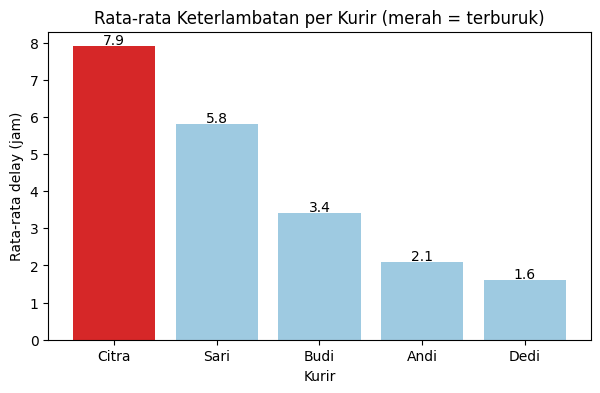

In [10]:
warna = ["#d62728" if k == rata_kurir.index[0] else "#9ecae1" for k in rata_kurir.index]
plt.figure(figsize=(7, 4))
plt.bar(rata_kurir.index, rata_kurir.values, color=warna)
plt.title("Rata-rata Keterlambatan per Kurir (merah = terburuk)")
plt.xlabel("Kurir")
plt.ylabel("Rata-rata delay (jam)")
for i, v in enumerate(rata_kurir.values):
    plt.text(i, v + 0.05, str(v), ha="center")
plt.show()

## 9. Korelasi terhadap Keterlambatan

In [11]:
korelasi = df[["distance_km", "weight_kg", "delay_hours"]].corr()["delay_hours"]
print("Korelasi jarak (distance_km) vs delay:", round(korelasi["distance_km"], 3))
print("Korelasi berat (weight_kg)   vs delay:", round(korelasi["weight_kg"], 3))
print()
faktor = "jarak" if abs(korelasi["distance_km"]) > abs(korelasi["weight_kg"]) else "berat"
print("Faktor yang lebih kuat hubungannya dengan keterlambatan:", faktor)

Korelasi jarak (distance_km) vs delay: 0.71
Korelasi berat (weight_kg)   vs delay: 0.22

Faktor yang lebih kuat hubungannya dengan keterlambatan: jarak


Nilai korelasi berkisar -1 sampai 1. Makin dekat ke 1, makin kuat hubungan searah (jarak naik, delay naik); makin dekat ke 0, makin lemah.

**Visualisasi korelasi (scatter plot + garis tren).** Setiap titik adalah satu paket. Garis merah menunjukkan arah hubungan: makin curam dan makin rapat titik-titiknya ke garis, makin kuat korelasinya.

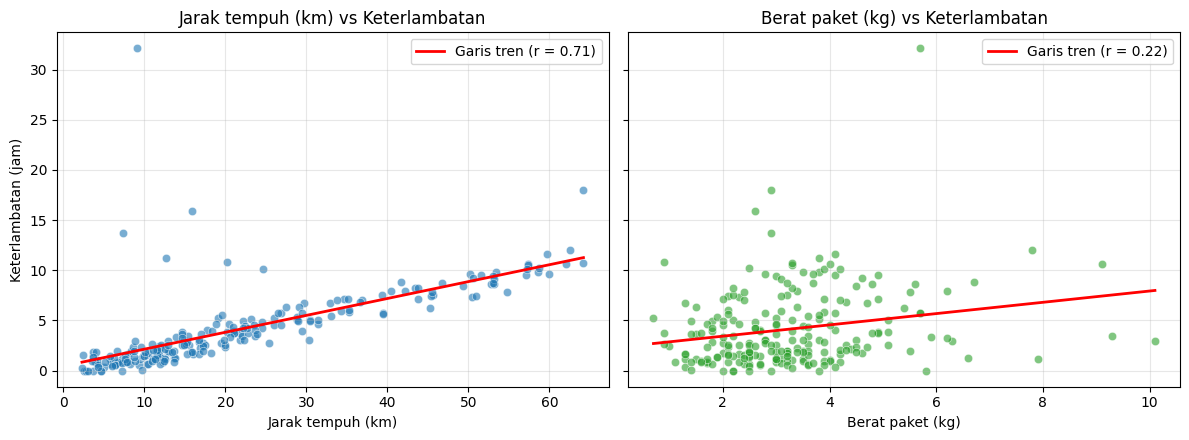

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, kolom, label, warna in [
    (axes[0], "distance_km", "Jarak tempuh (km)", "#1f77b4"),
    (axes[1], "weight_kg", "Berat paket (kg)", "#2ca02c"),
]:
    x = df[kolom].to_numpy()
    y = df["delay_hours"].to_numpy()

    # Titik-titik data
    ax.scatter(x, y, alpha=0.6, color=warna, edgecolor="white", linewidth=0.5)

    # Garis tren (regresi linear sederhana: y = m*x + b)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m * xs + b, color="red", linewidth=2, label=f"Garis tren (r = {korelasi[kolom]:.2f})")

    ax.set_title(f"{label} vs Keterlambatan")
    ax.set_xlabel(label)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Keterlambatan (jam)")
plt.tight_layout()
plt.show()

**Kesimpulan:** garis pada grafik jarak jauh lebih curam dan titiknya lebih menempel ke garis dibanding grafik berat. Jadi jarak tempuh adalah faktor yang lebih kuat memengaruhi keterlambatan.

## 10. Model Linear Regression

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["distance_km", "weight_kg"]]   # fitur (input)
y = df["delay_hours"]                  # target yang diprediksi

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data latih:", len(X_train), "baris | Data uji:", len(X_test), "baris")

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("\nKoefisien jarak:", round(model.coef_[0], 4), "jam per km")
print("Koefisien berat:", round(model.coef_[1], 4), "jam per kg")
print("MAE (rata-rata selisih prediksi) :", round(mean_absolute_error(y_test, pred), 2), "jam")
print("R2 (kemampuan model menjelaskan) :", round(r2_score(y_test, pred), 3))

Data latih: 176 baris | Data uji: 44 baris

Koefisien jarak: 0.1664 jam per km
Koefisien berat: 0.2357 jam per kg
MAE (rata-rata selisih prediksi) : 1.08 jam
R2 (kemampuan model menjelaskan) : 0.525


**Cara membaca:** MAE adalah rata-rata kesalahan prediksi dalam jam (makin kecil makin baik). R² mendekati 1 berarti model sangat akurat; mendekati 0 berarti model lemah.

## 11. Jarak Jauh vs Jarak Dekat & Insight Bisnis

In [14]:
jauh = df[df["distance_km"] > 50]
dekat = df[df["distance_km"] < 10]

rate_jauh = (jauh["delay_hours"] > batas_telat_jam).mean() * 100
rate_dekat = (dekat["delay_hours"] > batas_telat_jam).mean() * 100

print(f"Jarak jauh  (>50 km) : {len(jauh)} paket, telat >{batas_telat_jam} jam = {rate_jauh:.1f}%")
print(f"Jarak dekat (<10 km) : {len(dekat)} paket, telat >{batas_telat_jam} jam = {rate_dekat:.1f}%")
print(f"Rata-rata delay jauh  : {jauh['delay_hours'].mean():.2f} jam")
print(f"Rata-rata delay dekat : {dekat['delay_hours'].mean():.2f} jam")

Jarak jauh  (>50 km) : 24 paket, telat >2 jam = 100.0%
Jarak dekat (<10 km) : 54 paket, telat >2 jam = 9.3%
Rata-rata delay jauh  : 9.92 jam
Rata-rata delay dekat : 1.84 jam


In [15]:
if rate_dekat > 0:
    kali = f"{rate_jauh / rate_dekat:.1f}x lebih sering"
else:
    kali = "jauh lebih sering (jarak dekat tidak ada yang telat)"

insight = (f"Pengiriman di atas 50 km mengalami keterlambatan >{batas_telat_jam} jam "
           f"{kali} dibanding di bawah 10 km ({rate_jauh:.1f}% vs {rate_dekat:.1f}%), "
           f"sehingga janji waktu (promised_hours) untuk rute jauh perlu dilonggarkan "
           f"atau armada rute jauh perlu ditambah.")
print("INSIGHT BISNIS:")
print(insight)

INSIGHT BISNIS:
Pengiriman di atas 50 km mengalami keterlambatan >2 jam 10.8x lebih sering dibanding di bawah 10 km (100.0% vs 9.3%), sehingga janji waktu (promised_hours) untuk rute jauh perlu dilonggarkan atau armada rute jauh perlu ditambah.
